read dara by glob,  first work on bonnEEG dataset

In [ ]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import glob

pathname='/content'
filename= glob.glob(pathname+'/*')
print(filename)


['/content/S040.txt', '/content/S015.txt', '/content/S089.txt', '/content/S026.txt', '/content/S025.txt', '/content/S083.txt', '/content/S049.txt', '/content/S024.txt', '/content/S080.txt', '/content/S027.txt', '/content/S066.txt', '/content/S004.txt', '/content/S045.txt', '/content/S022.txt', '/content/S059.txt', '/content/S033.txt', '/content/S013.txt', '/content/S100.txt', '/content/S021.txt', '/content/S096.txt', '/content/S030.txt', '/content/S093.txt', '/content/S079.txt', '/content/S036.txt', '/content/S056.txt', '/content/S050.txt', '/content/S072.txt', '/content/S061.txt', '/content/S095.txt', '/content/S070.txt', '/content/S009.txt', '/content/S016.txt', '/content/S046.txt', '/content/S017.txt', '/content/S047.txt', '/content/S060.txt', '/content/S028.txt', '/content/S001.txt', '/content/S023.txt', '/content/S011.txt', '/content/S044.txt', '/content/S085.txt', '/content/S099.txt', '/content/S012.txt', '/content/S035.txt', '/content/S019.txt', '/content/S057.txt', '/content/S0

practice class

In [ ]:
class students:
  def __init__(self,name):
    self.name=name
  def __len__(self):
      return len(self.name)
  def __getitem__(self,index):
    return self.name[index]

names=['Jack','Martin','Ross']
p=students(names)
p[1]
# a=p.len()
# print(a)

'Martin'

Dataset and dataloader

In [ ]:
from torch.utils.data import Dataset,DataLoader
class CustomDataset(Dataset):
  def __init__(self,data,target):
    self.data=data
    self.target=target
  def __len__(self):
    return len(self.data)
  def __getitem__(self,index):
    x=self.data[index]
    y=self.target[index]
    return x,y

read dataset MNIST by torch

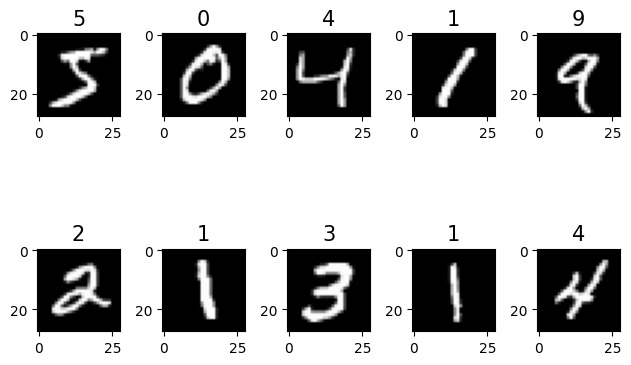

In [ ]:
import torch
from torchvision import datasets,transforms
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
import seaborn as sns

train_ds= datasets.MNIST(root='content/data',train=True,download=True,transform=ToTensor(),target_transform=None)
test_ds= datasets.MNIST(root='content/data',train=False,download=True,transform=ToTensor(),target_transform=None)
len(test_ds)

for i in range(10):

  sample,label=train_ds[i]

  plt.subplot(2,5,i+1)

  plt.imshow(sample.squeeze(), cmap='gray')

  plt.title(label,fontsize=15)

plt.tight_layout()

plt.show()


make customized dataset

In [ ]:
import torch
from torch.utils.data import Dataset,DataLoader
import glob
import pandas as pd

class CustomDataset(Dataset):
  def __init__(self,pathname,transforms=None,target_transform=None):
    self.file_names= glob.glob(pathname+'/*/*.txt') # Modified glob pattern
    self.class_map= {'S':0,'Z':1} # Changed keys to uppercase
    self.transforms=transforms
    self.target_transform=target_transform

  def __len__(self):
    return len(self.file_names)

  def __getitem__(self,index):
    filename= self.file_names[index]
    df= pd.read_csv(filename,header=None)
    chr=filename.split('/')[-1][0] # Modified split character

    sample=df.iloc[:,0].to_numpy()
    label=self.class_map[chr]
    if self.transforms:
      sample=self.transforms(sample)
    if self.target_transform:
      label=self.target_transform(label)
    return sample,label

In [ ]:
pathname='content'
ds=CustomDataset(pathname,transforms=None, target_transform=None)
len(ds)
sampl,label= ds[1]
print(sampl,label)

[-174 -392 -470 ...  187  157 -260] 0


another example for customize dataloader

In [ ]:
import torch
from torch.utils.data import Dataset,DataLoader
import glob
import pandas as pd

class CustomDataset(Dataset):
  def __init__(self,pathname,transforms=None,target_transform=None):
    df= pd.read_excel(pathname)
    data=df.iloc[:,:-1].to_numpy()
    label=df.iloc[:,-1].to_numpy()
    self.data=data
    self.target=label
    self.transforms=transforms
    self.target_transform=target_transform



  def __len__(self):
    return len(self.target)

  def __getitem__(self,index):
    sample= self.data[index]
    label=self.target[index]
    if self.transforms:
      sample=self.transforms(sample)
    if self.target_transform:
      label=self.target_transform(label)
    return sample,label

In [ ]:
pathname='content/iris.xlsx'
ds=CustomDataset(pathname,transforms=None, target_transform=None)
len(ds)
sampl,label= ds[11]
print(sampl,label)

[4.8 3.4 1.6 0.2] 1


create a dataset by pairing input data (data) with corresponding labels or outputs (target)
first method:

In [ ]:
data = [[1, 2], [3, 4], [5, 6]]  # Feature matrix (3 samples, 2 features each)
target = [0, 1, 0]               # Corresponding labels
ds = list(zip(data, target))
sampl,target= ds[2]
print(sampl,target)


[5, 6] 0


second method:

In [ ]:
from torch.utils.data import TensorDataset
data = [[1, 2], [3, 4], [5, 6]]  # Feature matrix (3 samples, 2 features each)
target = [0, 1, 0]               # Corresponding labels
data = torch.tensor(data, dtype=torch.float32)
target = torch.tensor(target, dtype=torch.long)
ds1=TensorDataset(data,target)
sampl,target= ds1[2]
print(sampl,target)




tensor([5., 6.]) tensor(0)


call method

In [ ]:
class Person:
  def __init__(self,name):
    self.name=name
  def __call__(self):
      print('my name is',self.name)


In [ ]:
p= Person('Jack')
p.name
p()

my name is Jack


In [ ]:
import torch
import numpy as np

class ToTensor:
    """
    A callable class that converts input data (list or NumPy array)
    into a PyTorch float tensor using the __call__ method.
    """
    def __init__(self):
        # The constructor does nothing here, as the state is simple (no attributes needed).
        pass

    # This method is automatically executed when the object instance is called like a function.
    def __call__(self, data):
        """Converts the input data into a PyTorch tensor."""
        print(f"Input Type received: {type(data)}")

        # Convert to tensor and ensure it's a float type (common for model input)
        tensor_output = torch.tensor(data, dtype=torch.float32)

        print(f"Output Tensor Shape: {tensor_output.shape}")
        return tensor_output

# --- Demonstration ---

# 1. Create an instance of the class
data_converter = ToTensor()

# 2. Prepare sample data (NumPy array)
sample_data = np.array([[1.0, 2.0], [3.0, 4.0]])

print("\n--- Calling the object like a function ---")

# 3. Call the instance directly to execute the __call__ method
tensor_result = data_converter(sample_data)

print("\nResulting Tensor:")
print(tensor_result)



--- Calling the object like a function ---
Input Type received: <class 'numpy.ndarray'>
Output Tensor Shape: torch.Size([2, 2])

Resulting Tensor:
tensor([[1., 2.],
        [3., 4.]])


compose and other method totensor and normalize

In [ ]:
import torch
import torchvision.transforms as T
import torchvision.datasets as datasets

transform1 = T.ToTensor()

transform2 = T.Normalize(
    mean=[0.5, 0.5, 0.5],
    std=[0.5, 0.5, 0.5]
)

transform = T.Compose([transform1, transform2])

print(f"Sequence: {transform}")

make transfor for label

In [ ]:
import torch
import numpy as np

class LabelToTensor:
    """
    A callable transform to convert a raw label (int, list, or numpy array)
    into a PyTorch LongTensor, suitable for classification targets.
    """
    # This is the method executed when the object is called like a function.
    def __call__(self, label):
        """
        Converts the label to a torch.LongTensor.
        Long is required by PyTorch loss functions (e.g., CrossEntropyLoss).
        """
        # Ensure the label is treated as a single item or a set of indices
        return torch.tensor(label, dtype=torch.long)

# --- Demonstration ---

# 1. Create the label transformation object
target_transform = LabelToTensor()

# 2. Sample raw label data
raw_label_int = 5
raw_label_np = np.array([1, 0, 3])

# 3. Apply the transform by calling the object directly
tensor_label_1 = target_transform(raw_label_int)
tensor_label_2 = target_transform(raw_label_np)

print(f"Raw Label (Int): {raw_label_int} -> Tensor Type: {tensor_label_1.dtype}, Value: {tensor_label_1}")
print(f"Raw Label (NumPy): {raw_label_np} -> Tensor Type: {tensor_label_2.dtype}, Value: {tensor_label_2}")


Raw Label (Int): 5 -> Tensor Type: torch.int64, Value: 5
Raw Label (NumPy): [1 0 3] -> Tensor Type: torch.int64, Value: tensor([1, 0, 3])


use MNIST dataset and and use lambda , to tensor and normlize for changing over sample and label, finnaly choose one image and show this.

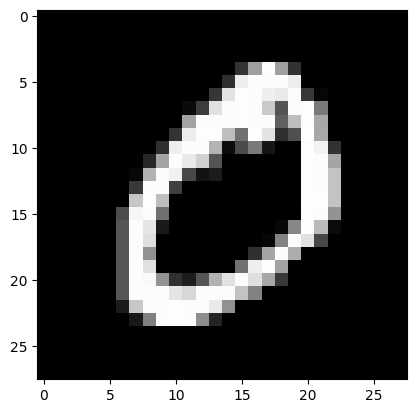

In [ ]:
import torch
import torchvision.transforms as T
from torchvision import datasets,transforms
from torchvision.transforms import ToTensor,Lambda,Normalize,Compose
import matplotlib.pyplot as plt
import seaborn as sns


train_ds= datasets.MNIST(root='content/data',train=True,download=True,transform=Compose(ToTensor(),Normalize(0,1)),target_transform=lambda y:torch.zeros(10,dtype=torch.float).scatter_(0,torch.tensor(y),value=1).type(torch.float32))
test_ds= datasets.MNIST(root='content/data',train=False,download=True,transform=ToTensor(),target_transform=lambda y:torch.zeros(10,dtype=torch.float).scatter_(0,torch.tensor(y),value=1).type(torch.float32))
len(test_ds)


sample,label=train_ds[1]
plt.imshow(sample.squeeze(), cmap='gray')
plt.show()


Learn batching:
Make custom dataloader with MNIST dataset and define class which return sample and label and also do batching and put 10 sample in one


In [ ]:
import torch
import torch.nn as nn
from torchvision.datasets import MNIST
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader

# --- 1. Define Custom Dataset Class ---

class CustomMNISTDataset(Dataset):
    """
    A custom Dataset class to wrap the raw MNIST data.
    It ensures data and labels are converted to PyTorch Tensors.
    """
    def __init__(self, root='./data', train=True, download=True):
        # Load the built-in MNIST dataset. We'll handle the tensor conversion
        # ourselves rather than using the 'transform' argument here.
        self.mnist = MNIST(root=root, train=train, download=download)

        # We only define one transformation for the features (image):
        # T.ToTensor converts the PIL Image to a float32 Tensor and normalizes to [0, 1].
        self.image_transform = T.ToTensor()

    def __len__(self):
        # This method is crucial: it tells the DataLoader the total size of the data.
        return len(self.mnist)

    def __getitem__(self, idx):
        """
        This method is called by the DataLoader to retrieve one sample (X, y)
        when given an index 'idx'.
        """
        # Retrieve the raw image (PIL object) and label (Python int)
        raw_image, raw_label = self.mnist[idx]

        # 1. Feature (X) Transformation
        # Convert the image to a float Tensor, shape (1, 28, 28), values [0, 1].
        image_tensor = self.image_transform(raw_image)

        # 2. Label (Y) Transformation
        # Convert the Python integer label to a torch.LongTensor.
        # torch.long is required for classification loss functions (e.g., CrossEntropyLoss).
        label_tensor = torch.tensor(raw_label, dtype=torch.long)

        # Return the processed sample and label
        return image_tensor, label_tensor

# --- 2. Initialize Dataset and DataLoader ---

# 1. Instantiate the custom dataset
print("Loading and preparing MNIST data...")
mnist_dataset = CustomMNISTDataset(train=True)

# 2. Instantiate the DataLoader (This handles batching)
# We set batch_size=10, and shuffle=True to randomize the order each epoch.
batch_size = 10
mnist_dataloader = DataLoader(
    dataset=mnist_dataset,
    batch_size=batch_size,
    shuffle=True
)

print(f"Total samples available: {len(mnist_dataset)}")
print(f"Configured batch size: {batch_size}")

# --- 3. Demonstrate Batching ---

# Iterate over the DataLoader to get the first batch
print("\nRetrieving the first batch from the DataLoader...")
for batch_images, batch_labels in mnist_dataloader:

    # Print the shape of the batch tensors
    print("Batch successfully loaded!")

    # Batch size (10), 1 channel, 28x28 pixels
    print(f"Image Batch Shape (N, C, H, W): {batch_images.shape}")

    # Batch size (10) for the labels
    print(f"Label Batch Shape (N): {batch_labels.shape}")

    # Stop after the first iteration
    break

print("\nDataLoader is ready for use in a training loop.")


Loading and preparing MNIST data...


100%|██████████| 9.91M/9.91M [00:00<00:00, 34.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.03MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.35MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.33MB/s]


Total samples available: 60000
Configured batch size: 10

Retrieving the first batch from the DataLoader...
Batch successfully loaded!
Image Batch Shape (N, C, H, W): torch.Size([10, 1, 28, 28])
Label Batch Shape (N): torch.Size([10])

DataLoader is ready for use in a training loop.
